In [42]:
import re
import pickle
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import nltk
nltk.download('stopwords')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/WELFake_Dataset.csv'   # <-- update if needed
news_dataset = pd.read_csv(DATA_PATH)

# Always check columns first when switching datasets — don't assume they match
print(news_dataset.columns.tolist())
news_dataset.head()

['Unnamed: 0', 'title', 'text', 'label']


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [44]:
# Drop an unnamed index column if present (common in this CSV export)
unnamed_cols = [c for c in news_dataset.columns if c.lower().startswith('unnamed')]
news_dataset = news_dataset.drop(columns=unnamed_cols, errors='ignore')

news_dataset.shape

(72134, 3)

In [45]:
print('Missing values:')
print(news_dataset.isnull().sum())

print('\nDuplicate title+text rows:', news_dataset.duplicated(subset=['title', 'text']).sum())

Missing values:
title    558
text      39
label      0
dtype: int64

Duplicate title+text rows: 8456


In [46]:
news_dataset = news_dataset.dropna(subset=['title', 'text'])
news_dataset = news_dataset.drop_duplicates(subset=['title', 'text'])

# Flip WELFake's label convention (0=fake,1=real) to match ours (1=fake,0=real)
news_dataset['label'] = 1 - news_dataset['label']

news_dataset.shape

(63121, 3)

In [47]:
# Keep the first N characters of the article body — plenty of signal,
# much faster to vectorize than full articles.
MAX_TEXT_CHARS = 1000

news_dataset['content'] = (
    news_dataset['title'].fillna('') + ' ' +
    news_dataset['text'].fillna('').str.slice(0, MAX_TEXT_CHARS)
)

In [48]:
port_stem = PorterStemmer()
english_stopwords = set(stopwords.words('english'))  # compute once, not per row — much faster

def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [
        port_stem.stem(word) for word in stemmed_content
        if word not in english_stopwords
    ]
    return ' '.join(stemmed_content)

In [49]:
news_dataset['content'] = news_dataset['content'].apply(stemming)
news_dataset['content'].head()

,content
0,law enforc high alert follow threat cop white ...
2,unbeliev obama attorney gener say charlott rio...
3,bobbi jindal rais hindu use stori christian co...
4,satan russia unv imag terrifi new supernuk wes...
5,time christian group sue amazon splc design ha...


In [50]:
X = news_dataset['content'].values
Y = news_dataset['label'].values

X_train_text, X_test_text, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

In [51]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
vectorizer.fit(X_train_text)

X_train = vectorizer.transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

X_train.shape, X_test.shape

((50496, 50000), (12625, 50000))

In [52]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=2),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
cv_results = {}

for name, clf in models.items():
    scores = cross_val_score(clf, X_train, Y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:28s} mean CV accuracy: {scores.mean():.4f}  (+/- {scores.std():.4f})')

Logistic Regression          mean CV accuracy: 0.9328  (+/- 0.0029)
Linear SVM                   mean CV accuracy: 0.9453  (+/- 0.0015)
Multinomial Naive Bayes      mean CV accuracy: 0.8649  (+/- 0.0035)
Passive Aggressive           mean CV accuracy: 0.9393  (+/- 0.0023)


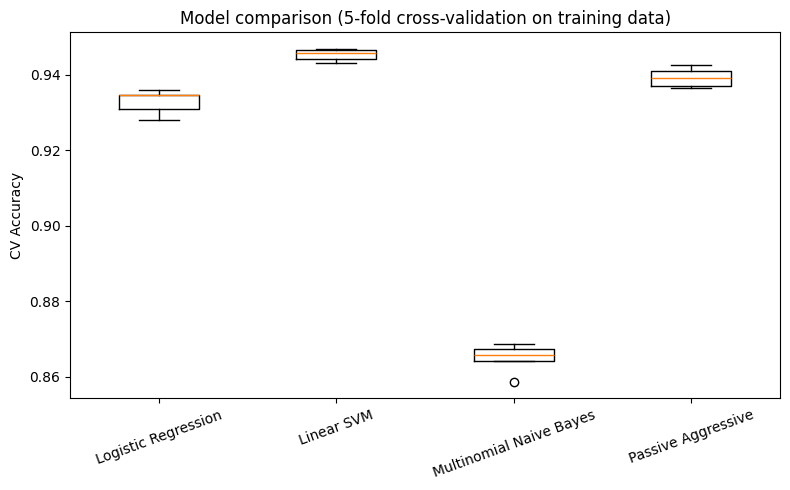

In [53]:
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.ylabel('CV Accuracy')
plt.title('Model comparison (5-fold cross-validation on training data)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [54]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, Y_train)

train_acc = accuracy_score(Y_train, best_model.predict(X_train))
test_acc = accuracy_score(Y_test, best_model.predict(X_test))

print(f'Train accuracy: {train_acc:.4f}')
print(f'Test accuracy:  {test_acc:.4f}')

Train accuracy: 0.9560
Test accuracy:  0.9404


              precision    recall  f1-score   support

    Real (0)       0.93      0.94      0.93      5666
    Fake (1)       0.95      0.94      0.95      6959

    accuracy                           0.94     12625
   macro avg       0.94      0.94      0.94     12625
weighted avg       0.94      0.94      0.94     12625



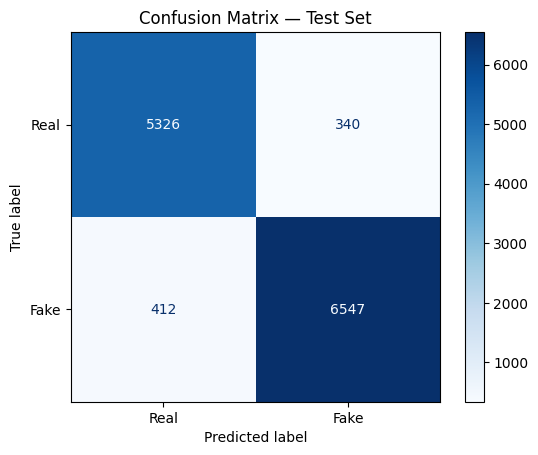

In [55]:
Y_pred = best_model.predict(X_test)

print(classification_report(Y_test, Y_pred, target_names=['Real (0)', 'Fake (1)']))

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.show()

In [56]:
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Saved tfidf.pkl and fake_news_model.pkl')

Saved tfidf.pkl and fake_news_model.pkl


In [57]:
sample_idx = 1
sample_vec = X_test[sample_idx]
pred = best_model.predict(sample_vec)[0]

print('Predicted:', 'Fake' if pred == 1 else 'Real')
print('Actual:   ', 'Fake' if Y_test[sample_idx] == 1 else 'Real')

Predicted: Fake
Actual:    Fake


In [58]:
# Confidence on an existing test sample (already vectorized as X_test)
example_idx = 1
proba = best_model.predict_proba(X_test[example_idx])[0]   # [P(Real), P(Fake)]
label = 'Fake' if proba[1] >= 0.5 else 'Real'
confidence = proba.max() * 100

print(f'Prediction: {label}  ({confidence:.1f}% confident)')
print(f'  P(Real) = {proba[0]*100:.1f}%   P(Fake) = {proba[1]*100:.1f}%')

Prediction: Fake  (98.1% confident)
  P(Real) = 1.9%   P(Fake) = 98.1%


In [60]:
def predict_with_confidence(title: str, text: str = '', threshold: float = 0.65):
    """Use this at inference time for brand-new, unseen articles.

    Returns 'Uncertain' instead of forcing a Real/Fake call when the model's
    top probability is below `threshold` — useful for catching inputs that
    are out-of-distribution for what the model was trained on.
    """
    raw_content = f'{title} {text[:MAX_TEXT_CHARS]}'
    cleaned = stemming(raw_content)
    vec = vectorizer.transform([cleaned])
    proba = best_model.predict_proba(vec)[0]
    confidence = proba.max() * 100

    if proba.max() < threshold:
        return 'Uncertain', confidence

    label = 'Fake' if proba[1] >= 0.5 else 'Real'
    return label, confidence

# Example with a brand-new headline
label, confidence = predict_with_confidence(
    title='Scientists confirm the moon is made of cheese',
    text='In a shocking discovery, researchers claim...'
)
print(f'Prediction: {label}  ({confidence:.1f}% confident)')

Prediction: Real  (89.0% confident)
